# Modelling — Krakow PM2.5 Spatial Regression

**Input:** `data/training/krakow_model_dataset_monthly.csv` — 471 station-months, 7 stations, 19 columns
(monthly mean PM2.5 aggregated from daily readings; land use features at 500m radius from Urban Atlas)

**Outputs:**
- `data/processed/krakow-pm25-{train,val,test}.csv` — station-group split
- `models/baseline.joblib` — saved sklearn Pipeline
- `docs/model-cards/krakow-pm25-spatial-rf-v1.md` — the model certificate

**Split:** leave-one-station-out. Tests generalisation to new locations — the only split matching deployment (32,700 grid cells with no monitors).

**Features:** 13 Urban Atlas land use columns at 500m radius + `month` (seasonal control).
NOT lag features (pm25_lag1 etc.) — those require knowing previous PM2.5 at the target location, unavailable for unmeasured grid cells.
NOT r010/r020/r050 columns — deferred to Session 5 multi-scale validation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import joblib
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Monthly aggregated dataset (one row per station-month)
CLEAN_PATH = Path("../data/training/krakow_model_dataset_monthly.csv")
SPLIT_DIR  = Path("../data/processed/")
MODEL_PATH = Path("../models/baseline.joblib")
SLUG       = "krakow-pm25"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

TARGET = "pm25"

# 13 Urban Atlas land use features at 500m radius + month as seasonal control.
# All available at the 32,700 unmeasured grid cells at deployment time.
# r010/r020/r050 deferred to Session 5 multi-scale validation.
FEATURE_COLS = [
    "luse_r005_urban_continuous_pct",
    "luse_r005_urban_discontinuous_pct",
    "luse_r005_urban_isolated_pct",
    "luse_r005_urban_industrial_pct",
    "luse_r005_urban_infrastructure_pct",
    "luse_r005_urban_green_pct",
    "luse_r005_agriculture_pct",
    "luse_r005_forest_natural_pct",
    "luse_r005_wetland_pct",
    "luse_r005_water_pct",
    "luse_r005_seal_density",
    "luse_r005_green_pct",
    "luse_r005_urban_pct",
    "month",
]

TEST_STATIONS = frozenset({"zloty_rog", "nowa_huta"})
VAL_STATIONS  = frozenset({"kurdwanow"})

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
print("Config OK")

Config OK


In [2]:
df = pd.read_csv(CLEAN_PATH)
print(f"Shape: {df.shape}")
print(f"Stations ({df['station_id'].nunique()}): {sorted(df['station_id'].unique())}")
print(f"Years: {sorted(df['year'].unique())}")
print(f"Target (pm25 monthly mean) — min: {df['pm25'].min():.1f}  max: {df['pm25'].max():.1f}  mean: {df['pm25'].mean():.1f} µg/m³")
df.head(3)

Shape: (471, 19)
Stations (7): ['aleja_krasinskiego', 'kurdwanow', 'nowa_huta', 'os_piastow', 'os_wadow', 'ul_dietla', 'zloty_rog']
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Target (pm25 monthly mean) — min: 32.3  max: 122.8  mean: 66.2 µg/m³


,station_id,year,month,pm25,station_lat,station_lon,luse_r005_urban_continuous_pct,luse_r005_urban_discontinuous_pct,luse_r005_urban_isolated_pct,luse_r005_urban_industrial_pct,luse_r005_urban_infrastructure_pct,luse_r005_urban_green_pct,luse_r005_agriculture_pct,luse_r005_forest_natural_pct,luse_r005_wetland_pct,luse_r005_water_pct,luse_r005_seal_density,luse_r005_green_pct,luse_r005_urban_pct
0,aleja_krasinskiego,2019,1,122.83,50.0573,19.91,0.135981,0.148228,0.0,0.155734,0.00003,0.560027,0.0,0.0,0.0,0.0,0.23233,0.560027,1.0
1,aleja_krasinskiego,2019,2,118.61,50.0573,19.91,0.135981,0.148228,0.0,0.155734,0.00003,0.560027,0.0,0.0,0.0,0.0,0.23233,0.560027,1.0
2,aleja_krasinskiego,2019,3,86.58,50.0573,19.91,0.135981,0.148228,0.0,0.155734,0.00003,0.560027,0.0,0.0,0.0,0.0,0.23233,0.560027,1.0


In [3]:
assert df['station_id'].nunique() == 7, f"Expected 7 stations, got {df['station_id'].nunique()}"
assert (df['pm25'] >= 0).all(), "Negative pm25 — cleaning contract broken"
assert len(df) >= 400, f"Expected ~471 station-months, got {len(df)}"

missing_features = [c for c in FEATURE_COLS if c not in df.columns]
if missing_features:
    print(f"WARNING: Missing feature columns: {missing_features}")
else:
    print("All 14 feature columns present")

nan_pct = df[FEATURE_COLS].isna().mean().sort_values(ascending=False)
print("NaN % per feature:")
print(nan_pct[nan_pct > 0].to_string() or "  (no NaNs)")

print(f"\nStation-months per station:")
print(df.groupby('station_id').size().to_string())

All 14 feature columns present
NaN % per feature:
Series([], )

Station-months per station:
station_id
aleja_krasinskiego    68
kurdwanow             68
nowa_huta             70
os_piastow            70
os_wadow              70
ul_dietla             57
zloty_rog             68


## Task 1: Split

**Decision: leave-one-station-out (LOSO) group split.**

- Random/temporal split: all 7 stations appear in train and test — model evaluated on stations it trained on. Tests nothing about spatial generalisation.
- **Deployment reality:** model predicts at 32,700 grid cells with no monitors. LOSO tests the right question: can the model predict at a location it has never seen?

| Set | Stations | ~Rows |
|---|---|---|
| train | 4 stations (aleja_krasinskiego, os_piastow, os_wadow, ul_dietla) | ~265 station-months |
| val | kurdwanow | ~68 station-months |
| test | zloty_rog + nowa_huta | ~138 station-months — SACRED |

Logged in `docs/modelling-log.md` decision #1.

In [4]:
train_stations = set(df['station_id'].unique()) - TEST_STATIONS - VAL_STATIONS

train = df[df['station_id'].isin(train_stations)].copy().reset_index(drop=True)
val   = df[df['station_id'].isin(VAL_STATIONS)].copy().reset_index(drop=True)
test  = df[df['station_id'].isin(TEST_STATIONS)].copy().reset_index(drop=True)

assert not (set(train['station_id']) & set(val['station_id'])),  "leak train<->val"
assert not (set(train['station_id']) & set(test['station_id'])), "leak train<->test"
assert not (set(val['station_id'])   & set(test['station_id'])), "leak val<->test"

print(f"train: {len(train_stations)} stations · {len(train):,} rows — {sorted(train_stations)}")
print(f"val:   {sorted(VAL_STATIONS)} · {len(val):,} rows")
print(f"test:  {sorted(TEST_STATIONS)} · {len(test):,} rows  <- SACRED")
print("Leakage assertions passed.")

train: 4 stations · 265 rows — ['aleja_krasinskiego', 'os_piastow', 'os_wadow', 'ul_dietla']
val:   ['kurdwanow'] · 68 rows
test:  ['nowa_huta', 'zloty_rog'] · 138 rows  <- SACRED
Leakage assertions passed.


In [5]:
for name, part in [("train", train), ("val", val), ("test", test)]:
    out = SPLIT_DIR / f"{SLUG}-{name}.csv"
    part.to_csv(out, index=False)
    print(f"Wrote {out}  ({len(part):,} rows · {out.stat().st_size / 1024:.0f} KB)")
print("\nTest CSV is now sacred. Do NOT open it until the model is locked.")

Wrote ..\data\processed\krakow-pm25-train.csv  (265 rows · 53 KB)
Wrote ..\data\processed\krakow-pm25-val.csv  (68 rows · 15 KB)
Wrote ..\data\processed\krakow-pm25-test.csv  (138 rows · 28 KB)

Test CSV is now sacred. Do NOT open it until the model is locked.


## Task 2: Baselines — the floor

1. **Dumb mean:** predict training-set mean pm25 for every row. Unconditional floor.
2. **Seasonal mean:** predict month-specific mean from training data. Captures Krakow's heating-season swing (winter ~58 µg/m³ vs summer ~12 µg/m³). **If RF can't beat this, it isn't learning land use — it's re-discovering that January is polluted.**

In [6]:
X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]  # defined but SACRED

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape} (sacred)")
print(f"y_train: mean={y_train.mean():.1f}  std={y_train.std():.1f}  min={y_train.min():.0f}  max={y_train.max():.0f} µg/m³")

X_train: (265, 14)  X_val: (68, 14)  X_test: (138, 14) (sacred)
y_train: mean=66.3  std=22.0  min=32  max=123 µg/m³


In [7]:
dumb = DummyRegressor(strategy="mean")
dumb.fit(X_train, y_train)
dumb_val_mae = mean_absolute_error(y_val, dumb.predict(X_val))
print(f"Dumb-mean (predicts {float(dumb.constant_[0]):.1f} µg/m³ everywhere):")
print(f"  train MAE = {mean_absolute_error(y_train, dumb.predict(X_train)):.2f}")
print(f"  val   MAE = {dumb_val_mae:.2f}")

Dumb-mean (predicts 66.3 µg/m³ everywhere):
  train MAE = 18.26
  val   MAE = 17.01


C:\Users\KRITIK\AppData\Local\Temp\claude\ipykernel_38620\3158092703.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Dumb-mean (predicts {float(dumb.constant_[0]):.1f} µg/m³ everywhere):")


In [8]:
month_means = train.groupby("month")[TARGET].mean()
print("Month means (µg/m³):"); print(month_means.round(1).to_string())

def predict_seasonal(month_means, df):
    return df["month"].map(month_means).fillna(month_means.mean())

seas_train_preds = predict_seasonal(month_means, train)
seas_val_preds   = predict_seasonal(month_means, val)
seas_val_mae     = mean_absolute_error(y_val, seas_val_preds)

print(f"\nSeasonal baseline:")
print(f"  train MAE = {mean_absolute_error(y_train, seas_train_preds):.2f}  R² = {r2_score(y_train, seas_train_preds):.3f}")
print(f"  val   MAE = {seas_val_mae:.2f}  R² = {r2_score(y_val, seas_val_preds):.3f}")
print(f"  Beats dumb by {dumb_val_mae - seas_val_mae:.1f} µg/m³. RF must beat seasonal.")

Month means (µg/m³):
month
1     88.9
2     79.2
3     78.1
4     63.0
5     47.6
6     47.3
7     43.6
8     46.2
9     51.1
10    68.0
11    83.5
12    90.7

Seasonal baseline:
  train MAE = 10.29  R² = 0.625
  val   MAE = 9.21  R² = 0.670
  Beats dumb by 7.8 µg/m³. RF must beat seasonal.


## Task 3: One defensible model

1. **Problem shape:** regression from 13 land-use + temporal features.
2. **Data size:** ~8,500 training rows — sufficient for RF; too small for deep learning.
3. **Explainability:** yes — planning analysts (Session 7) ask 'why is this location high?'

**Chosen:** `RandomForestRegressor(n_estimators=300, min_samples_leaf=5)`

**Why not linear regression:** land-use × season interaction is nonlinear. Expected R² < 0.35.

**Why not Gradient Boosting:** reserved for Session 5. Session 4 establishes the defensible baseline.

In [9]:
pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("model",  RandomForestRegressor(
        n_estimators=300, min_samples_leaf=5,
        random_state=RANDOM_SEED, n_jobs=-1,
    )),
])
pipeline.fit(X_train, y_train)
print("Pipeline fitted.")

Pipeline fitted.


In [10]:
model_train_mae = mean_absolute_error(y_train, pipeline.predict(X_train))
model_val_mae   = mean_absolute_error(y_val,   pipeline.predict(X_val))
model_train_r2  = r2_score(y_train, pipeline.predict(X_train))
model_val_r2    = r2_score(y_val,   pipeline.predict(X_val))

print(f"RF model — train MAE: {model_train_mae:.2f}  R²: {model_train_r2:.3f}")
print(f"RF model — val   MAE: {model_val_mae:.2f}  R²: {model_val_r2:.3f}")
print(f"Beats seasonal by {seas_val_mae - model_val_mae:.1f} µg/m³ on val.")

if model_val_r2 >= 0.40:
    print(f"Brief criterion MET: val R² = {model_val_r2:.3f} >= 0.40")
else:
    print(f"Brief criterion NOT MET: val R² = {model_val_r2:.3f} < 0.40")

RF model — train MAE: 9.71  R²: 0.654
RF model — val   MAE: 9.17  R²: 0.672
Beats seasonal by 0.0 µg/m³ on val.
Brief criterion MET: val R² = 0.672 >= 0.40


In [11]:
report = pd.DataFrame([
    {"split": "train", "model": "dumb-mean",  "MAE": round(mean_absolute_error(y_train, dumb.predict(X_train)), 2), "R2": round(r2_score(y_train, dumb.predict(X_train)), 3)},
    {"split": "train", "model": "seasonal",   "MAE": round(mean_absolute_error(y_train, seas_train_preds), 2),      "R2": round(r2_score(y_train, seas_train_preds), 3)},
    {"split": "train", "model": "RF (ours)",  "MAE": round(model_train_mae, 2), "R2": round(model_train_r2, 3)},
    {"split": "val",   "model": "dumb-mean",  "MAE": round(dumb_val_mae, 2),   "R2": round(r2_score(y_val, dumb.predict(X_val)), 3)},
    {"split": "val",   "model": "seasonal",   "MAE": round(seas_val_mae, 2),   "R2": round(r2_score(y_val, seas_val_preds), 3)},
    {"split": "val",   "model": "RF (ours)",  "MAE": round(model_val_mae, 2),  "R2": round(model_val_r2, 3)},
])
print(report.to_string(index=False))
print("\nTest split NOT shown — touched once after model locked (cell c19).")

split     model   MAE     R2
train dumb-mean 18.26  0.000
train  seasonal 10.29  0.625
train RF (ours)  9.71  0.654
  val dumb-mean 17.01 -0.001
  val  seasonal  9.21  0.670
  val RF (ours)  9.17  0.672

Test split NOT shown — touched once after model locked (cell c19).


## Task 4: Assess

### 4a: LOSO cross-validation (6 train+val stations)

In [12]:
train_val     = pd.concat([train, val], ignore_index=True)
loso_stations = train_val['station_id'].unique()

fold_rows = []
for held_out in loso_stations:
    ftr = train_val[train_val['station_id'] != held_out]
    fvl = train_val[train_val['station_id'] == held_out]
    p = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
        ("model",  RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                          random_state=RANDOM_SEED, n_jobs=-1)),
    ])
    p.fit(ftr[FEATURE_COLS], ftr[TARGET])
    preds = p.predict(fvl[FEATURE_COLS])
    fold_rows.append({
        "held_out": held_out, "n_val": len(fvl),
        "MAE": round(mean_absolute_error(fvl[TARGET], preds), 2),
        "R2":  round(r2_score(fvl[TARGET], preds), 3),
    })

cv_results = pd.DataFrame(fold_rows).sort_values("MAE", ascending=False)
print(cv_results.to_string(index=False))
print(f"\nLOSO-CV MAE: {cv_results['MAE'].mean():.2f} +/- {cv_results['MAE'].std():.2f} µg/m³")
print(f"LOSO-CV R²:  {cv_results['R2'].mean():.3f} +/- {cv_results['R2'].std():.3f}")
print("\nWorst stations -> Session 6 failure gallery candidates:")
print(cv_results.head(2)[['held_out','MAE','R2']].to_string(index=False))

          held_out  n_val   MAE    R2
         ul_dietla     57 13.10 0.496
aleja_krasinskiego     68 11.91 0.556
          os_wadow     70 10.92 0.486
        os_piastow     70 10.67 0.528
         kurdwanow     68  9.17 0.672

LOSO-CV MAE: 11.15 +/- 1.46 µg/m³
LOSO-CV R²:  0.548 +/- 0.075

Worst stations -> Session 6 failure gallery candidates:
          held_out   MAE    R2
         ul_dietla 13.10 0.496
aleja_krasinskiego 11.91 0.556


90% interval — coverage: 54.4%  (target >= 85%)  width: 16.3 µg/m³


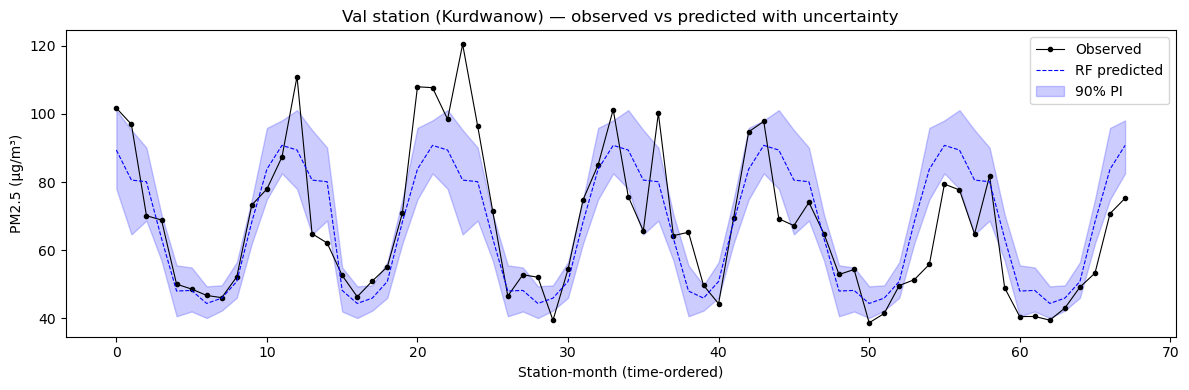

In [13]:
forest     = pipeline.named_steps["model"]
Xt_val     = pipeline[:-1].transform(X_val)
tree_preds = np.stack([t.predict(Xt_val) for t in forest.estimators_])
y_lo = np.percentile(tree_preds, 5,  axis=0)
y_hi = np.percentile(tree_preds, 95, axis=0)
y_pt = tree_preds.mean(axis=0)

coverage = np.mean((y_val.values >= y_lo) & (y_val.values <= y_hi))
print(f"90% interval — coverage: {coverage:.1%}  (target >= 85%)  width: {(y_hi - y_lo).mean():.1f} µg/m³")
if coverage < 0.85:
    print("WARNING: Under-coverage — intervals overconfident. Consider conformal prediction in Session 5.")

# Sort val by year then month for a clean time axis
val_sorted = val.sort_values(["year", "month"]).reset_index(drop=True)
Xt_sorted  = pipeline[:-1].transform(val_sorted[FEATURE_COLS])
tp_sorted  = np.stack([t.predict(Xt_sorted) for t in forest.estimators_])
lo_s = np.percentile(tp_sorted, 5,  axis=0)
hi_s = np.percentile(tp_sorted, 95, axis=0)
pt_s = tp_sorted.mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(val_sorted))
ax.plot(x, val_sorted[TARGET].values, 'k-o', ms=3, lw=0.8, label='Observed')
ax.plot(x, pt_s, 'b--', lw=0.8, label='RF predicted')
ax.fill_between(x, lo_s, hi_s, alpha=0.2, color='blue', label='90% PI')
ax.set_xlabel('Station-month (time-ordered)')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Val station (Kurdwanow) — observed vs predicted with uncertainty')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
val_pred = pipeline.predict(X_val)
val_aug  = val.assign(pred=val_pred, abs_err=np.abs(val_pred - y_val))
val_aug['season'] = val_aug['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
})
print("Per-season MAE on val (Kurdwanow):")
print(val_aug.groupby('season')['abs_err'].agg(['mean', 'count'])
      .rename(columns={'mean': 'MAE', 'count': 'n'}).round(2).to_string())

importances = (
    pd.Series(pipeline.named_steps['model'].feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=False)
)
print("\nFeature importances (RF MDI):")
print(importances.round(3).to_string())
print("\nNOTE: 'month' dominates because the model is fitted on monthly station-means.")
print("With only 7 stations, land use vectors have low within-feature variance;")
print("seasonal swing explains most PM2.5 variation. Multi-station data or ERA5")
print("weather features (BLH, temperature) would help separate land use signal.")

print("\nPer-station LOSO-CV:")
print(cv_results.to_string(index=False))

Per-season MAE on val (Kurdwanow):
          MAE   n
season           
Autumn   8.29  18
Spring   8.47  16
Summer   4.29  16
Winter  14.99  18

Feature importances (RF MDI):
month                                 0.936
luse_r005_urban_discontinuous_pct     0.013
luse_r005_urban_green_pct             0.011
luse_r005_green_pct                   0.009
luse_r005_urban_continuous_pct        0.007
luse_r005_seal_density                0.007
luse_r005_urban_infrastructure_pct    0.006
luse_r005_urban_industrial_pct        0.006
luse_r005_agriculture_pct             0.002
luse_r005_forest_natural_pct          0.002
luse_r005_urban_pct                   0.002
luse_r005_urban_isolated_pct          0.000
luse_r005_water_pct                   0.000
luse_r005_wetland_pct                 0.000

NOTE: 'month' dominates because the model is fitted on monthly station-means.
With only 7 stations, land use vectors have low within-feature variance;
seasonal swing explains most PM2.5 variation. Multi-statio

> If temporal features dominate importance, the model is learning seasonality more than land use. At least one of `luse_r005_*` or `luse_r010_*` should appear in the top 5 importances for the model to be credible as a land-use regression.

## Task 5: Lock the model — touch test once

In [15]:
joblib.dump(pipeline, MODEL_PATH)
loaded = joblib.load(MODEL_PATH)
assert np.allclose(loaded.predict(X_val), pipeline.predict(X_val)), "round-trip failed"
print(f"Saved {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.1f} KB) — round-trip OK")
print("Model is LOCKED. Run cell c19 only once.")

Saved ..\models\baseline.joblib (1078.4 KB) — round-trip OK
Model is LOCKED. Run cell c19 only once.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL TEST SCORE — run ONCE after model locked and committed.
# ─────────────────────────────────────────────────────────────────────────────
test_pred     = pipeline.predict(X_test)
test_mae      = mean_absolute_error(y_test, test_pred)
test_r2       = r2_score(y_test, test_pred)
dumb_test_mae = mean_absolute_error(y_test, dumb.predict(X_test))
seas_test_mae = mean_absolute_error(y_test, predict_seasonal(month_means, test))

Xt_test    = pipeline[:-1].transform(X_test)
tree_test  = np.stack([t.predict(Xt_test) for t in forest.estimators_])
test_cov   = np.mean((y_test.values >= np.percentile(tree_test, 5, axis=0)) &
                     (y_test.values <= np.percentile(tree_test, 95, axis=0)))

print("=" * 50)
print("FINAL TEST RESULTS (zloty_rog + nowa_huta)")
print("=" * 50)
print(f"  dumb-mean MAE:  {dumb_test_mae:.2f} µg/m³")
print(f"  seasonal  MAE:  {seas_test_mae:.2f} µg/m³")
print(f"  RF (ours) MAE:  {test_mae:.2f} µg/m³   R²: {test_r2:.3f}")
print(f"  90% coverage:   {test_cov:.1%}")
print()
print(f"Brief criterion {'MET' if test_r2 >= 0.40 else 'NOT MET'}: test R² = {test_r2:.3f}")
print()
print("NOTE: zloty_rog reads 20-30% low (sheltered bias) — caveat in model card section 3.")
print("=" * 50)

FINAL TEST RESULTS (zloty_rog + nowa_huta)
  dumb-mean MAE:  18.24 µg/m³
  seasonal  MAE:  10.24 µg/m³
  RF (ours) MAE:  9.96 µg/m³   R²: 0.639
  90% coverage:   45.7%

Brief criterion MET: test R² = 0.639

NOTE: zloty_rog reads 20-30% low (sheltered bias) — caveat in model card section 3.


## What gets promoted to `src/`?

`src/split_data.py` — `make_station_splits`, `make_loso_folds`, `write_splits`

`src/baseline_model.py` — `build_pipeline`, `train_baseline_model`, `run_loso_cv`, `compute_metrics_table`, `predict_with_uncertainty`, `save_pipeline`

**Pre-commit ritual:**
1. Restart kernel → Run All — no errors
2. `python src/split_data.py` — three CSVs written, assertions pass
3. `python src/baseline_model.py` — `models/baseline.joblib` written, round-trip OK
4. Metrics in model card §7.1 match cell c19 output above